---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Análise Exploratória: entendendo os reviews</h1>

<h3 align="center">Ângelo Rosa</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

## 1. Contexto e objetivo

**Objetivo:** entender o banco `data/reviews.db` antes de modelar. A leitura aqui é só de consulta
(SQL + pandas): estrutura, qualidade, distribuições, evolução no tempo. Cada achado aponta para uma
decisão nos módulos seguintes.

O recorte vem do notebook 01: **todos os reviews da categoria `All_Beauty` em 2021**, sem
amostragem. Como é o ano inteiro, o que se mede aqui descreve a população, não uma amostra dela, e
a comparação entre meses é direta.

**Perguntas que guiam a análise:**

- Como as notas se distribuem, e quão desbalanceado fica o rótulo de sentimento? (módulo 2)
- Como o volume de reviews e a satisfação se movem ao longo do ano?
- Quanto texto existe por review, e o que isso impõe ao pré-processamento? (módulo 2)

Nada é gravado no banco neste notebook.

In [1]:
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

from config import ANO_ALVO, CATEGORIA, DB_PATH
from utils.sql import query_sql

conn = sqlite3.connect(DB_PATH)

print("banco:", DB_PATH, "| categoria:", CATEGORIA, "| ano:", ANO_ALVO)

banco: data/reviews.db | categoria: All_Beauty | ano: 2021


## 2. Estrutura e volume

Duas tabelas: `products` (uma linha por produto) e `reviews` (uma linha por avaliação, com chave
para o produto).

In [2]:
schema = query_sql(conn, """
SELECT name AS tabela,
       (SELECT COUNT(*) FROM pragma_table_info(m.name)) AS n_colunas
FROM sqlite_master m
WHERE type = 'table'
""")
schema["n_linhas"] = [query_sql(conn, f"SELECT COUNT(*) FROM {t}").iloc[0, 0]
                      for t in schema["tabela"]]
schema

,tabela,n_colunas,n_linhas
0,products,7,112590
1,reviews,10,111851


In [3]:
# Colunas de reviews (o contrato que os próximos módulos consomem)
query_sql(conn, "SELECT name, type FROM pragma_table_info('reviews')")

,name,type
0,review_id,INTEGER
1,product_id,TEXT
2,user_id,TEXT
3,asin,TEXT
4,rating,REAL
5,title,TEXT
6,text,TEXT
7,review_date,TEXT
8,helpful_vote,INTEGER
9,verified_purchase,INTEGER


## 3. Qualidade dos dados

Antes de qualquer estatística, medir o que está faltando ou fora de faixa. Nulos em colunas que os
próximos módulos consomem são um problema; nulos em colunas acessórias, nem tanto.

In [3]:
checks = {
    "notas fora de 1-5":     "SELECT COUNT(*) FROM reviews WHERE rating < 1 OR rating > 5",
    "texto nulo ou vazio":   "SELECT COUNT(*) FROM reviews WHERE text IS NULL OR TRIM(text) = ''",
    "título nulo ou vazio":  "SELECT COUNT(*) FROM reviews WHERE title IS NULL OR TRIM(title) = ''",
    "reviews sem produto":   """SELECT COUNT(*) FROM reviews r
                                LEFT JOIN products p ON p.product_id = r.product_id
                                WHERE p.product_id IS NULL""",
    "produtos sem preço":    "SELECT COUNT(*) FROM products WHERE price IS NULL",
}
pd.DataFrame([{"verificação": nome, "n": query_sql(conn, sql).iloc[0, 0]}
              for nome, sql in checks.items()])

,verificação,n
0,notas fora de 1-5,0
1,texto nulo ou vazio,0
2,título nulo ou vazio,0
3,reviews sem produto,0
4,produtos sem preço,94886


Nenhum nulo nas colunas que o módulo 2 consome: nota, título, texto e a chave para o produto estão
completos nos 111.851 reviews. O filtro de 20 caracteres do notebook 01 já garante que não existe
texto vazio.

O preço, por outro lado, falta em 94.886 dos 112.590 produtos, cerca de 84%. Não é erro de coleta,
é assim na fonte, e a consequência é direta: o preço fica fora de qualquer modelo daqui em diante.

## 4. Distribuição de notas e o rótulo de sentimento

O rótulo de sentimento é derivado da nota: 1-2 negativo, 3 neutro, 4-5 positivo. É um rótulo fraco
(a nota nem sempre reflete o texto), mas é o sinal disponível para todos os reviews. O gráfico
abaixo já antecipa o problema central do módulo 2: **forte desbalanceamento**.

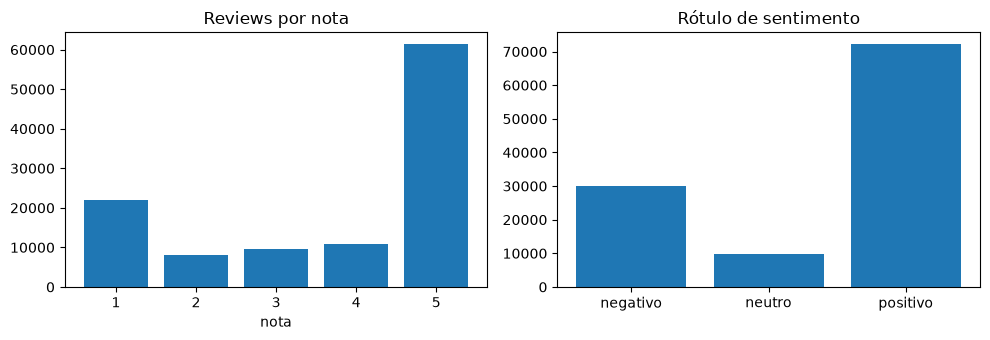

,sentimento,n,%
0,negativo,30080,26.9
1,neutro,9654,8.6
2,positivo,72117,64.5


In [4]:
notas = query_sql(conn, "SELECT rating, COUNT(*) AS n FROM reviews GROUP BY rating")
sentimento = query_sql(conn, """
SELECT CASE WHEN rating <= 2 THEN 'negativo'
            WHEN rating = 3  THEN 'neutro' ELSE 'positivo' END AS sentimento,
       COUNT(*) AS n
FROM reviews GROUP BY sentimento
""")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.bar(notas["rating"], notas["n"])
ax1.set_title("Reviews por nota"); ax1.set_xlabel("nota")
ax2.bar(sentimento["sentimento"], sentimento["n"])
ax2.set_title("Rótulo de sentimento")
fig.tight_layout(); plt.show()

sentimento["%"] = (100 * sentimento["n"] / sentimento["n"].sum()).round(1)
sentimento

Duas coisas para reter.

A distribuição de notas é em **J**: a nota 5 domina com 61.310 reviews, mas a nota 1 vem em segundo
(21.923), à frente da nota 4 (10.807). Quem escreve review costuma estar muito satisfeito ou muito
insatisfeito; a opinião morna raramente vira texto.

No rótulo de sentimento isso vira 64,5% de positivo, 26,9% de negativo e **8,6% de neutro**.
Consequências para o módulo 2: acurácia bruta engana (prever sempre "positivo" já acerta dois terços
dos casos), então a métrica principal será **F1-macro**, e o treino tratará o desbalanceamento. A
classe neutra tem 9.654 exemplos, o que é pouco em proporção mas suficiente em volume absoluto para
treinar.

## 5. Evolução ao longo do ano

Como o volume de reviews e a satisfação se moveram de janeiro a dezembro de 2021. São os 12 meses
completos, então a comparação entre eles não depende de nenhuma correção.

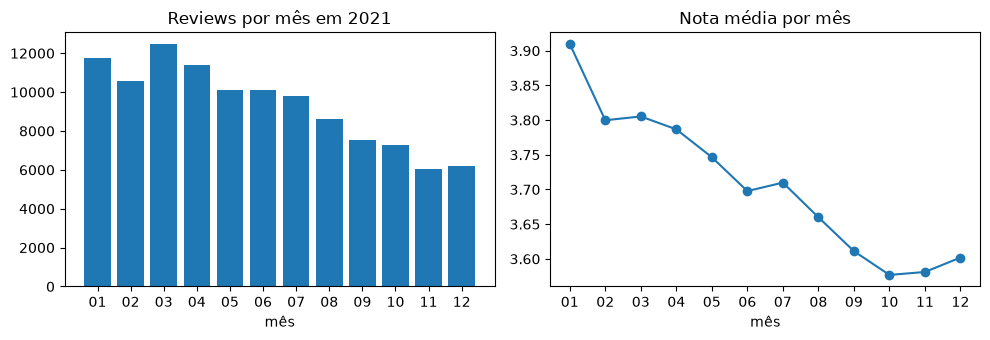

In [5]:
por_mes = query_sql(conn, """
SELECT strftime('%m', review_date) AS mes, COUNT(*) AS n, AVG(rating) AS nota
FROM reviews GROUP BY mes
""")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.bar(por_mes["mes"], por_mes["n"])
ax1.set_title(f"Reviews por mês em {ANO_ALVO}"); ax1.set_xlabel("mês")
ax2.plot(por_mes["mes"], por_mes["nota"], marker="o")
ax2.set_title("Nota média por mês"); ax2.set_xlabel("mês")
fig.tight_layout(); plt.show()

As duas séries caem juntas ao longo do ano. O volume vai de 11.768 reviews em janeiro para 6.028 em
novembro, praticamente metade, e a nota média acompanha, de 3,91 para 3,58.

A EDA descreve esse padrão, mas não tem como explicá-lo, e vale dizer isso ao aluno: pode ser o
consumo normalizando depois do pico de compras da pandemia, pode ser efeito de como o dataset foi
montado, e este notebook não distingue as duas hipóteses. O registro importa porque, se o módulo 2
encontrar o sentimento piorando ao longo de 2021, boa parte desse movimento já está aqui, antes de
qualquer modelo.

## 6. Texto dos reviews

O comprimento do texto importa para o módulo 2: textos longos são truncados antes de virar
embedding, e textos muito curtos carregam pouco sinal.

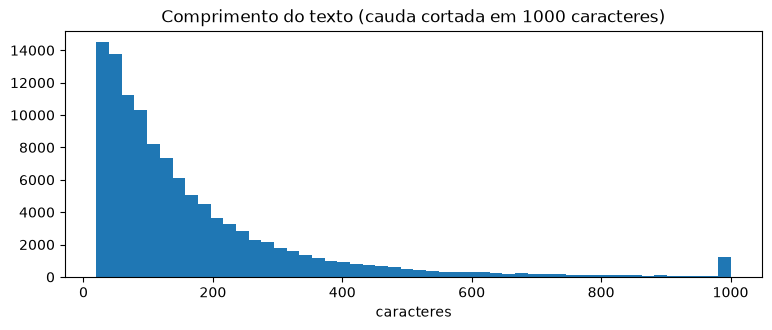

count    111851.0
mean        176.0
std         231.0
min          20.0
25%          59.0
50%         112.0
75%         212.0
max       14989.0
Name: n_chars, dtype: float64

In [8]:
tamanhos = query_sql(conn, "SELECT LENGTH(text) AS n_chars FROM reviews")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(tamanhos["n_chars"].clip(upper=1000), bins=50)
ax.set_title("Comprimento do texto (cauda cortada em 1000 caracteres)")
ax.set_xlabel("caracteres"); plt.show()

tamanhos["n_chars"].describe().round(0)

A distribuição é bem assimétrica: metade dos reviews tem até **112 caracteres**, a média é 176 por
causa da cauda, e o maior tem quase 15 mil. O mínimo de 20 é o filtro do notebook 01.

Para o módulo 2, isso quer dizer que o truncamento em 1000 caracteres afeta pouquíssimos reviews, e
que a maior parte do conjunto são textos curtos, de uma ou duas frases.

## 7. Síntese: o que isto decide nos próximos módulos

- **Desbalanceamento das classes** (módulo 2): 64,5% positivo, 26,9% negativo, 8,6% neutro. Daí
  F1-macro como métrica principal e tratamento explícito do desbalanceamento no treino; a classe
  neutra será a mais difícil.
- **Rótulo derivado da nota é fraco no meio**: a distribuição em J mostra que quem escreve review
  tende aos extremos, então a nota 3 reúne justamente os textos ambivalentes.
- **Texto sempre presente, preço quase sempre ausente**: o NLP se apoia no texto, e o preço fica
  fora dos modelos.
- **Textos curtos**: mediana de 112 caracteres, então o truncamento do módulo 2 quase não morde.
- **Volume e satisfação caem juntos ao longo de 2021**: parte da variação de sentimento não vem do
  texto, e sim de quando o review foi escrito.

In [9]:
conn.close()